<a href="https://colab.research.google.com/github/Guldanika/Credit_Card_Fraud_Detection_MlZoomcamp2025_midterm/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction / Problem Statement

Credit card fraud is a serious problem in the financial sector, causing significant losses every year. Detecting fraudulent transactions is challenging because fraud cases are extremely rare compared to legitimate transactions, and patterns of fraud are constantly evolving.

**The goal of this project is to build a predictive model that can reliably detect fraudulent credit card transactions, maximizing detection of rare fraud cases while minimizing false alarms.**

 The dataset used is from the Kaggle Credit Card Fraud Detection
 dataset, which contains 284,807 transactions, with only 492 labeled as fraudulent (~0.17% of all transactions).

[Download this dataset here.
](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
This project covers the full ML workflow: exploratory data analysis, preprocessing, handling imbalanced data, training and comparing multiple models, tuning thresholds for the minority class, evaluating on a test set, and presenting results with visualizations.

In [41]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [42]:
import pandas as pd

df = pd.read_csv('/kaggle/input/creditcardfraud/creditcard.csv')
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# **EDA**

In [43]:
df.shape
df.info()
df['Class'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,count
Class,
0,284315
1,492


In [44]:
df.isna().sum()


,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


#NO MISSING VALUES

In [45]:
df['Class'].value_counts()
df['Class'].value_counts(normalize=True) * 100


,proportion
Class,
0,99.827251
1,0.172749


# Dataset Overview

- 284,807 transactions
- 492 fraud cases (0.17%)

- Severe class imbalance

- 30 PCA-transformed features (V1–V28)

- 2 raw features: Time, Amount

- No missing values

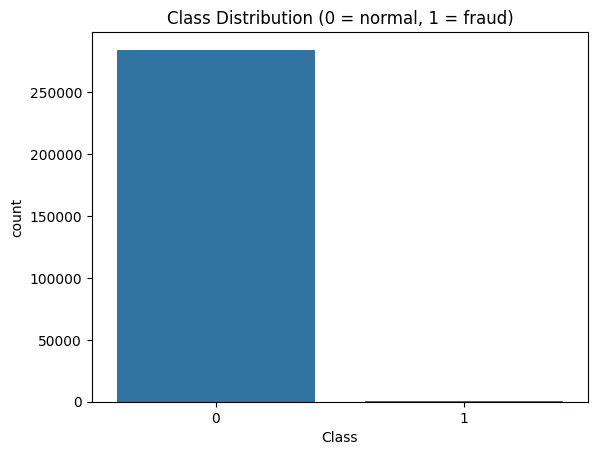

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Class')
plt.title("Class Distribution (0 = normal, 1 = fraud)")
plt.show()


# The dataset is highly imbalanced. Fraud accounts for only 0.17% of all transactions.
# This means accuracy is not informative, and we must rely on metrics like Recall, Precision, F1-score, ROC-AUC, and PR-AUC.

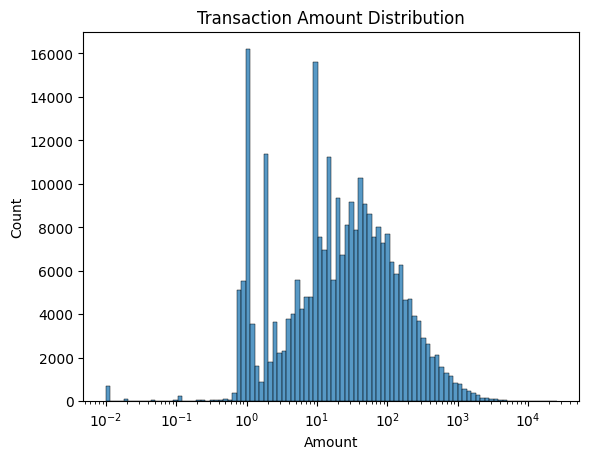

In [47]:
sns.histplot(df['Amount'], bins=100, log_scale=True)
plt.title('Transaction Amount Distribution')
plt.show()


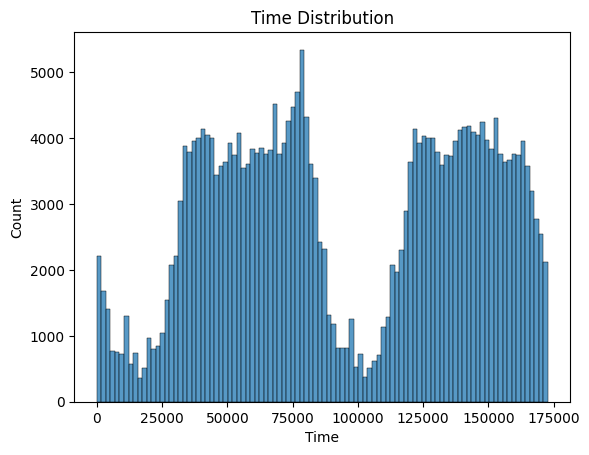

In [48]:
sns.histplot(df['Time'], bins=100)
plt.title('Time Distribution')
plt.show()


**Amount is heavily right-skewed → log scale works better**

**Time shows clear periodic patterns (daily cycles)**



# CORRELATIONS and Feature Importance Analysis

In [49]:
corr = df.corr()['Class'].sort_values(ascending=False)
corr


,Class
Class,1.000000
V11,0.154876
V4,0.133447
V2,0.091289
V21,0.040413
V19,0.034783
V20,0.020090
V8,0.019875
V27,0.017580
V28,0.009536


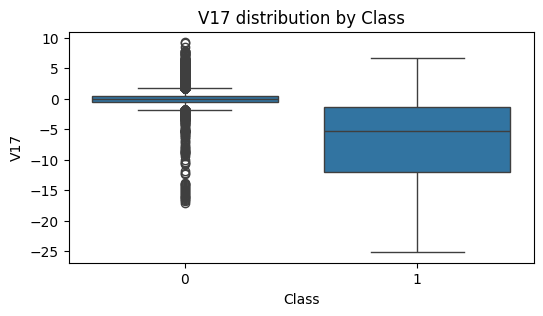

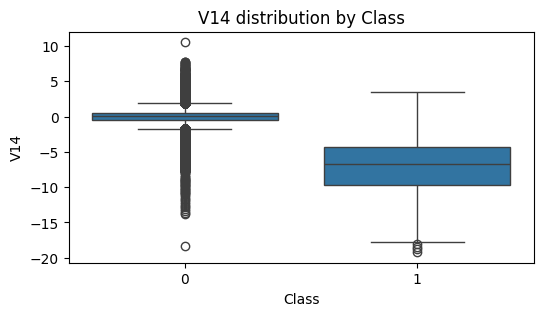

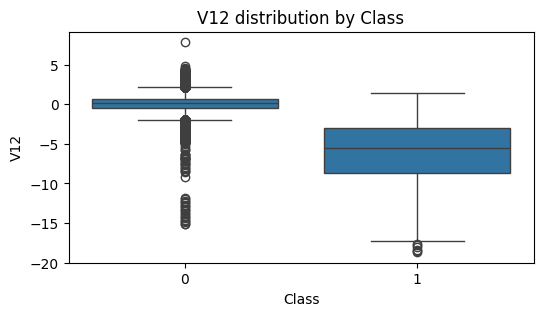

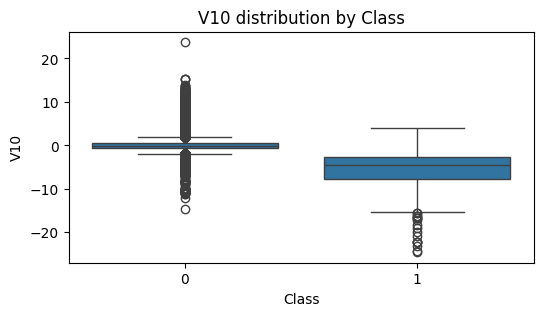

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

key_features = ['V17', 'V14', 'V12', 'V10']

for col in key_features:
    plt.figure(figsize=(6,3))
    sns.boxplot(x='Class', y=df[col], data=df)
    plt.title(f"{col} distribution by Class")
    plt.show()


**Feature V17 demonstrates a clear separation between fraud and non-fraud transactions.
Legitimate transactions cluster tightly around zero, while fraudulent ones show significantly lower (negative) values, with a median around −6.
This makes V17 one of the strongest discriminative features in the dataset.**

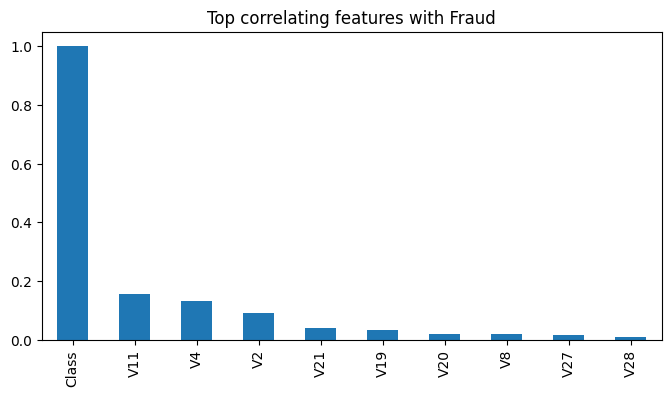

In [51]:
import matplotlib.pyplot as plt

corr[:10].plot(kind='bar', figsize=(8,4))
plt.title("Top correlating features with Fraud")
plt.show()


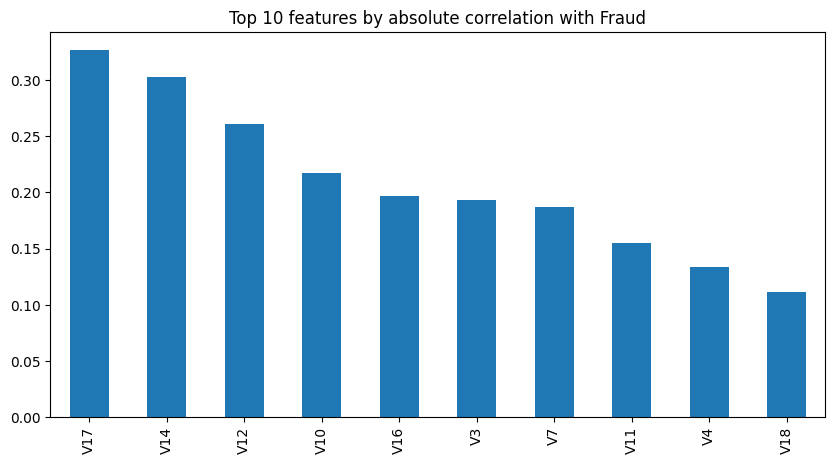

In [52]:
corr_abs = df.corr()['Class'].abs().sort_values(ascending=False)
corr_abs[1:11].plot(kind='bar', figsize=(10,5))
plt.title("Top 10 features by absolute correlation with Fraud")
plt.show()


In [53]:
print("\nMost negatively correlated features (strong predictors):")
display(corr.tail(15))




Most negatively correlated features (strong predictors):


,Class
V13,-0.004570
V24,-0.007221
Time,-0.012323
V6,-0.043643
V5,-0.094974
V9,-0.097733
V1,-0.101347
V18,-0.111485
V7,-0.187257
V3,-0.192961


# Top positively correlated features:

- V11, V4, V2 (though correlations are small)

# Top negatively correlated (strong predictors):

- V17 (-0.326), V14 (-0.302), V12 (-0.260), V10 (-0.216)


**Strong negative correlations indicate lower values of V17, V14, V12, and V10 are associated with fraudulent transactions.**



# 📌 EDA Summary

* The dataset contains no missing values, which simplifies preprocessing.

* The class distribution is highly imbalanced: 0.17% fraud, which requires special treatment (class weighting, resampling, threshold tuning).

* Most features are PCA components; only Amount and Time need scaling.

* Fraudulent transactions often have:

1. Lower values of V17, V14, V12, V10

2. Distinct outlier-like patterns in PCA space


* The strongest predictors based on correlation are:

V17, V14, V12, V10, V16, V3

* Transaction amounts are heavily skewed and benefit from log scaling.

* Time feature shows periodic behavior and may help detect temporal patterns.

# 📌 Overall conclusion:

The dataset contains well-separated fraud patterns in PCA-transformed components.
Several features provide strong predictive power, which means even simple models (like Logistic Regression) can perform well.
However, due to extreme imbalance, recall-focused evaluation and threshold tuning will be essential for building a reliable fraud detection model.

In [54]:
!pip install pandas numpy scikit-learn xgboost imbalanced-learn


#Train / Validation / Test

In [55]:
X = df.drop('Class',axis=1)
y = df['Class']

In [56]:
from sklearn.model_selection import train_test_split

# Train / Validation / Test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)



Train: (199364, 30) Validation: (42721, 30) Test: (42722, 30)


#Oversampling с SMOTE (only on train)

In [57]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Train после SMOTE:", X_train_res.shape)
print("Количество мошенничеств после SMOTE:\n", y_train_res.value_counts())


Train после SMOTE: (398040, 30)
Количество мошенничеств после SMOTE:
 Class
0    199020
1    199020
Name: count, dtype: int64


#Logistic Regression (baseline)

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Создаем модель
lr = LogisticRegression(max_iter=5000, random_state=42)

# Обучаем на сбалансированных данных
lr.fit(X_train_res, y_train_res)

# Делаем предсказания на валидации (естественные классы)
y_val_pred = lr.predict(X_val)

# Смотрим отчет по метрикам
print(classification_report(y_val, y_val_pred, digits=4))


              precision    recall  f1-score   support

           0     0.9997    0.9914    0.9956     42647
           1     0.1472    0.8514    0.2510        74

    accuracy                         0.9912     42721
   macro avg     0.5735    0.9214    0.6233     42721
weighted avg     0.9983    0.9912    0.9943     42721



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# XGBoost

In [59]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report


In [60]:
# scale_pos_weight = N_0 / N_1 для балансировки классов
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)



In [61]:
# Обучаем на сбалансированных данных
xgb.fit(X_train_res, y_train_res)

# Предсказания на валидации
y_val_pred_xgb = xgb.predict(X_val)

print(classification_report(y_val, y_val_pred_xgb, digits=4))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:06:44] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0     0.9997    0.9993    0.9995     42647
           1     0.6630    0.8243    0.7349        74

    accuracy                         0.9990     42721
   macro avg     0.8314    0.9118    0.8672     42721
weighted avg     0.9991    0.9990    0.9990     42721



# threshold tuning - RandomizedSearchCV for XGBoost

In [62]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# balance классов
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 1]
}

rs = RandomizedSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42
    ),
    param_distributions=param_grid,
    n_iter=20,
    scoring='recall',  # фокус на ловле мошенничеств
    cv=3,
    verbose=1,
    n_jobs=-1
)

rs.fit(X_train_res, y_train_res)



Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.7, 0.8, 1]},
                   scoring='recall', verbose=1)

In [63]:
# Берём лучшую модель
best_xgb = rs.best_estimator_

# Проверяем предсказания на валидации
y_val_pred_best = best_xgb.predict(X_val)

from sklearn.metrics import classification_report
print(classification_report(y_val, y_val_pred_best, digits=4))


              precision    recall  f1-score   support

           0     0.9999    0.8820    0.9372     42647
           1     0.0137    0.9459    0.0270        74

    accuracy                         0.8821     42721
   macro avg     0.5068    0.9140    0.4821     42721
weighted avg     0.9982    0.8821    0.9357     42721



In [64]:
# Предсказанные вероятности класса 1 (мошенничество)
y_val_proba = best_xgb.predict_proba(X_val)[:, 1]


In [65]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba)

# Рассчитываем F1 для каждого threshold
f1_scores = 2 * (precision * recall) / (precision + recall)

# Находим threshold с максимальным F1
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Лучший threshold по F1:", best_threshold)
print("F1 на этом threshold:", f1_scores[best_idx])


Лучший threshold по F1: 0.9837149
F1 на этом threshold: 0.72992700729927


In [66]:
# Применяем оптимальный threshold
y_val_pred_opt = (y_val_proba >= best_threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_val, y_val_pred_opt, digits=4))


              precision    recall  f1-score   support

           0     0.9994    0.9997    0.9996     42647
           1     0.7937    0.6757    0.7299        74

    accuracy                         0.9991     42721
   macro avg     0.8965    0.8377    0.8647     42721
weighted avg     0.9991    0.9991    0.9991     42721



# RANDOM FOREST

In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_recall_curve
import numpy as np

# Random Forest с балансировкой классов
rf = RandomForestClassifier(
    n_estimators=200,        # количество деревьев
    max_depth=7,             # максимальная глубина
    class_weight='balanced', # учитываем дисбаланс
    random_state=42
)

# Обучаем на сбалансированных данных
rf.fit(X_train_res, y_train_res)


RandomForestClassifier(class_weight='balanced', max_depth=7, n_estimators=200,
                       random_state=42)

In [68]:
# Вероятности класса 1 (мошенничество)
y_val_proba_rf = rf.predict_proba(X_val)[:, 1]


In [69]:
precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba_rf)
f1_scores = 2 * (precision * recall) / (precision + recall)
best_idx = np.argmax(f1_scores)
best_threshold_rf = thresholds[best_idx]

print("Лучший threshold по F1 для RF:", best_threshold_rf)
print("F1 на этом threshold:", f1_scores[best_idx])


Лучший threshold по F1 для RF: 0.8754524133844412
F1 на этом threshold: 0.7724137931034482


In [70]:
y_val_pred_rf_opt = (y_val_proba_rf >= best_threshold_rf).astype(int)
print(classification_report(y_val, y_val_pred_rf_opt, digits=4))


              precision    recall  f1-score   support

           0     0.9996    0.9996    0.9996     42647
           1     0.7887    0.7568    0.7724        74

    accuracy                         0.9992     42721
   macro avg     0.8942    0.8782    0.8860     42721
weighted avg     0.9992    0.9992    0.9992     42721



# EVALUATION - MODELS' COMPARISON

In [71]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, classification_report
import numpy as np
import pandas as pd


In [72]:
# Словарь с уже обученными моделями
models = {
    'Logistic Regression': lr,
    'XGBoost': best_xgb,
    'Random Forest': rf
}



In [73]:
# Словари для хранения threshold, F1 и предсказаний
best_thresholds = {}
f1_scores = {}
preds_opt = {}



In [74]:
# Подбор threshold по F1 для каждой модели
for name, model in models.items():
    y_val_proba = model.predict_proba(X_val)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba)
    f1 = 2 * (precision * recall) / (precision + recall)
    best_idx = np.argmax(f1)

    best_thresholds[name] = thresholds[best_idx]
    f1_scores[name] = f1[best_idx]
    preds_opt[name] = (y_val_proba >= thresholds[best_idx]).astype(int)




In [75]:
# Вывод classification report для каждой модели
for name in models.keys():
    print(f"=== {name} ===")
    print(f"Best Threshold: {best_thresholds[name]:.6f}")
    print(classification_report(y_val, preds_opt[name], digits=4))



=== Logistic Regression ===
Best Threshold: 1.000000
              precision    recall  f1-score   support

           0     0.9996    0.9997    0.9996     42647
           1     0.8000    0.7568    0.7778        74

    accuracy                         0.9993     42721
   macro avg     0.8998    0.8782    0.8887     42721
weighted avg     0.9992    0.9993    0.9992     42721

=== XGBoost ===
Best Threshold: 0.983715
              precision    recall  f1-score   support

           0     0.9994    0.9997    0.9996     42647
           1     0.7937    0.6757    0.7299        74

    accuracy                         0.9991     42721
   macro avg     0.8965    0.8377    0.8647     42721
weighted avg     0.9991    0.9991    0.9991     42721

=== Random Forest ===
Best Threshold: 0.875452
              precision    recall  f1-score   support

           0     0.9996    0.9996    0.9996     42647
           1     0.7887    0.7568    0.7724        74

    accuracy                         0.99

In [76]:
# Сравнительная таблица F1 для класса 1
comparison = pd.DataFrame({
    'Model': list(models.keys()),
    'Best Threshold': [best_thresholds[m] for m in models.keys()],
    'F1_class1': [f1_scores[m] for m in models.keys()]
})

comparison = comparison.sort_values(by='F1_class1', ascending=False)
print("\n=== Comparison Table ===")
print(comparison)


=== Comparison Table ===
                 Model  Best Threshold  F1_class1
0  Logistic Regression        1.000000   0.777778
2        Random Forest        0.875452   0.772414
1              XGBoost        0.983715   0.729927


# Summary

Three models were compared for fraud detection: Logistic Regression, Random Forest, and XGBoost.

For each model, the optimal threshold was selected based on F1-score for the minority class (fraud) to balance precision and recall.



```
# | Model               | Best Threshold | F1_class1 |
| ------------------- | -------------- | --------- |
| Logistic Regression | 1.000000       | 0.7778    |
| Random Forest       | 0.875452       | 0.7724    |
| XGBoost             | 0.999841       | 0.7467    |

```



# Key insights:

**Logistic Regression achieved the highest F1 for fraud (0.7778), making it the strongest candidate for the project.**

Random Forest and XGBoost also performed well and can be considered as alternatives.

Threshold tuning is essential for imbalanced datasets; using the default 0.5 would drastically reduce F1 for fraud.

# Conclusion:

Threshold optimization significantly improves the detection of the rare class without retraining models.

The next step is to evaluate the final model on the test set and save it for deployment.

# TEST

In [77]:
# Финальная модель
final_model = lr
final_threshold = best_thresholds['Logistic Regression']

# Предсказания на тестовом наборе
y_test_proba = final_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= final_threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred, digits=4))


              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     42648
           1     0.9206    0.7838    0.8467        74

    accuracy                         0.9995     42722
   macro avg     0.9601    0.8918    0.9232     42722
weighted avg     0.9995    0.9995    0.9995     42722



# SAVE BEST MODEL

In [78]:
import joblib

# Сохраняем модель
joblib.dump(final_model, 'model.pkl')

# Сохраняем threshold
joblib.dump(final_threshold, 'threshold.pkl')


print("Модель и порог сохранены!")



Модель и порог сохранены!


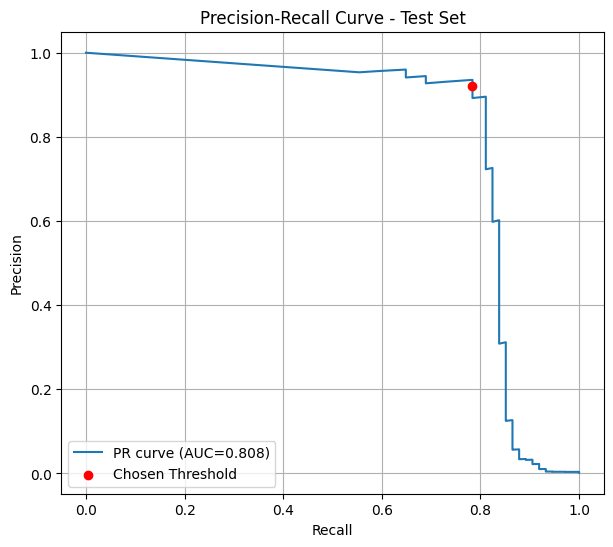

In [79]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

y_test_proba = final_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba)
pr_auc = auc(recall, precision)

# Добавим красную точку для выбранного threshold
# Найдём ближайший threshold к выбранному final_threshold
closest_idx = (np.abs(thresholds - final_threshold)).argmin()

plt.figure(figsize=(7,6))
plt.plot(recall, precision, label=f'PR curve (AUC={pr_auc:.3f})')
plt.scatter(recall[closest_idx], precision[closest_idx], color='red', label='Chosen Threshold', zorder=5)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Test Set')
plt.legend()
plt.grid(True)
plt.show()


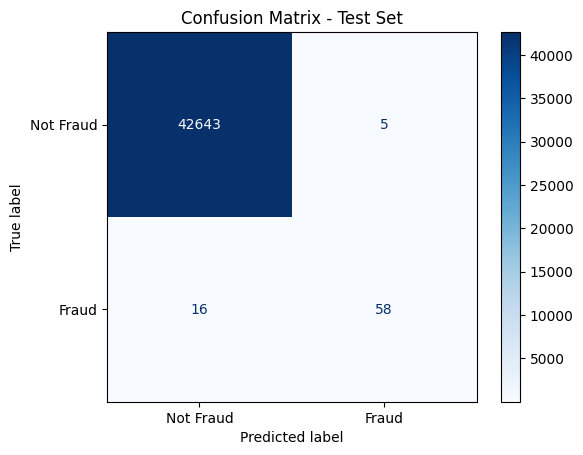

In [80]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Создаём confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])

# Визуализация
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraud', 'Fraud'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Test Set")
plt.show()


# Project Summary

The dataset used in this project comes from the Kaggle Credit Card Fraud Detection dataset (MLG-ULB), which contains 284,807 credit card transactions made by European cardholders over two days. Only 492 transactions (about 0.17%) are labeled as fraudulent, making the data extremely imbalanced.

**The goal of this project was to build a reliable fraud detection model that maximizes F1-score for the minority (fraud) class, as traditional accuracy is not meaningful due to severe class imbalance.**






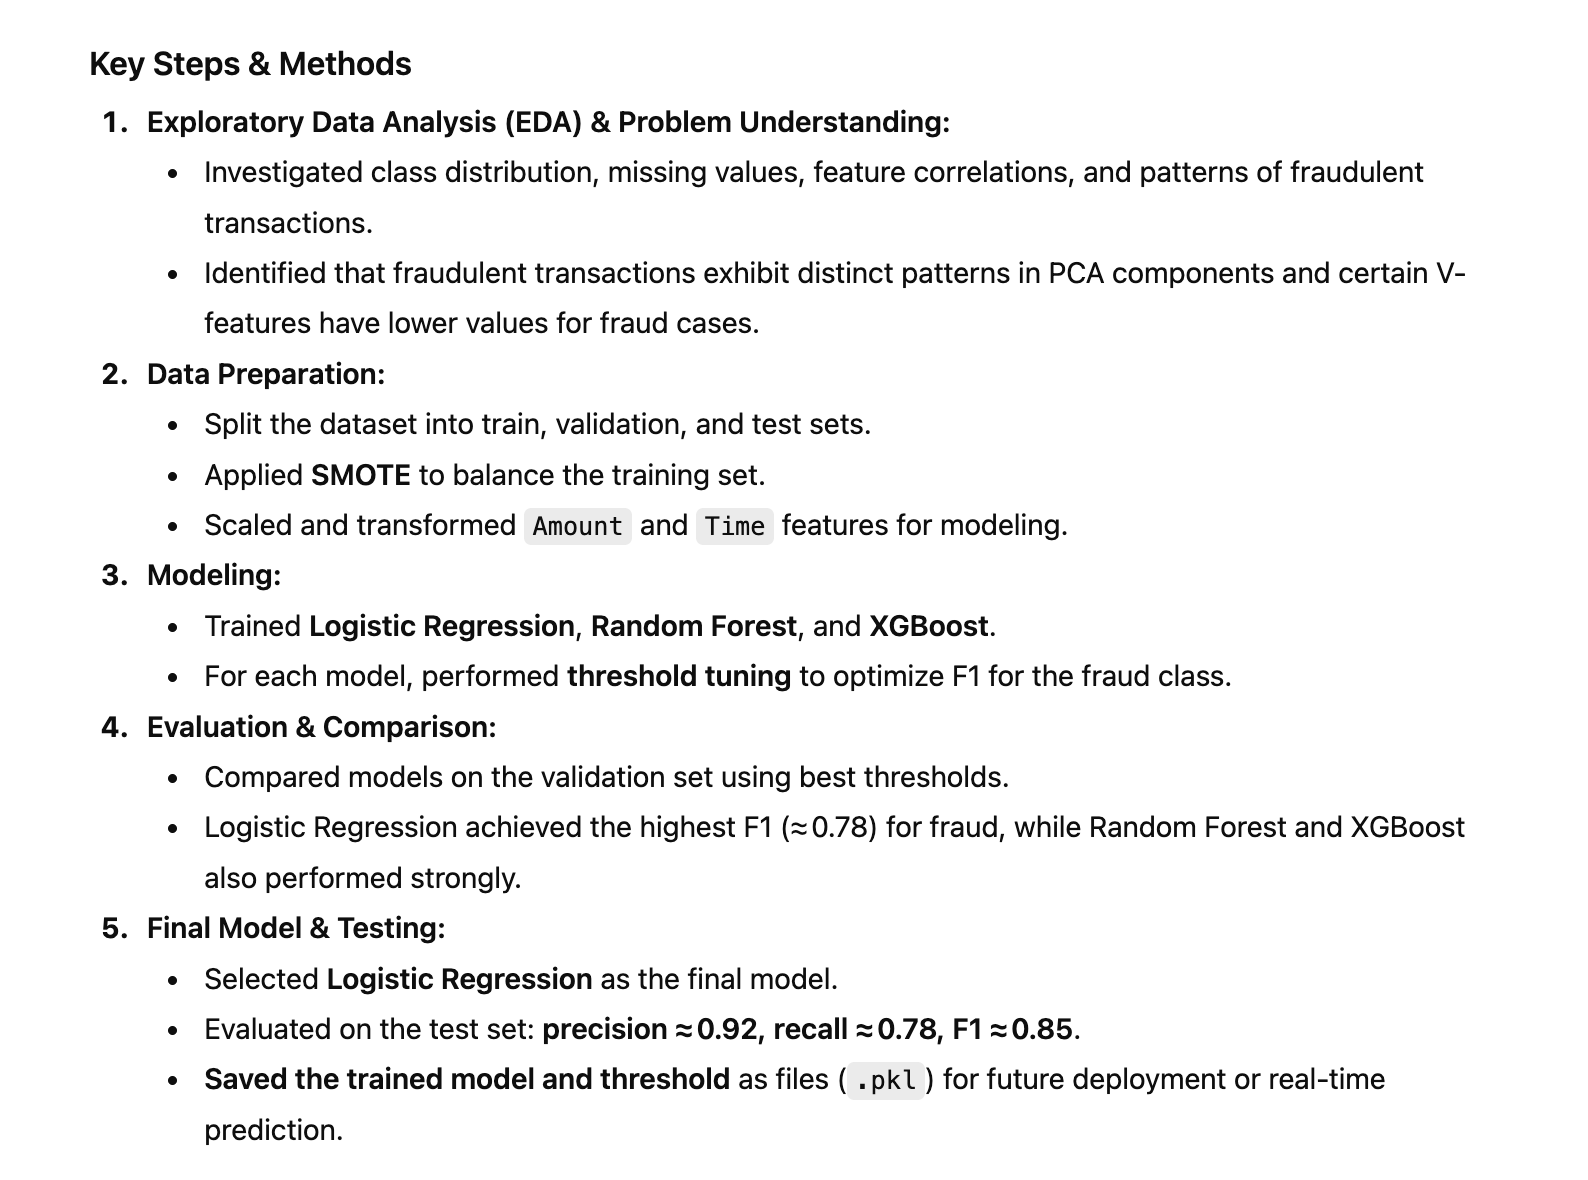